# GRPO Vision Sanity Check & Story Evaluation
This notebook runs a 100-sample sanity check on the **Qwen3-VL-4B-Thinking** model using GRPO. 
It features a raw inference block before fine-tuning. The reward function ranks generation alignments with the reference narrative (via cosine similarity). 
We then evaluate the outputs using an LLM-as-a-judge (`gemma-4-31b-it` via `GEMINI_FREE_API_KEY_1`) following the **AIStory Similarity Benchmark**.

In [ ]:
%pip cache purge
%pip install unsloth
%pip install transformers==4.57.0
%pip install --no-deps trl==0.26.2
%pip install pillow python-dotenv datasets sentence-transformers google-genai vllm
%pip uninstall torch torchvision -y
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
%pip install ipywidgets

In [1]:
import os
import re
import gc
import json
import random
import torch
torch._dynamo.config.disable = True
import torch.nn.functional as F
from PIL import Image
import copy
import matplotlib.pyplot as plt
import math
from dotenv import load_dotenv
from datasets import Dataset
from transformers import AutoProcessor, TextStreamer
from sentence_transformers import SentenceTransformer
from trl import GRPOConfig, GRPOTrainer
from unsloth import FastVisionModel, is_bfloat16_supported
from google import genai
from google.genai import types

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.1+cu118).
W0506 23:59:04.603000 17616 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
C:\Users\VINH\AppData\Local\Temp\ipykernel_17616\1846151382.py:18: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel, is_bfloat16_supported


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"Torch version: {torch.__version__}")


Is CUDA available: True
Torch version: 2.7.1+cu118


## 1. Data Preparation
We'll replicate the core logic from `generate_cot_and_story.py` to load 100 sequences and dynamically resolve image paths from `data/final/train`.

In [ ]:
import os
import zipfile
from huggingface_hub import snapshot_download

# 1. Cấu hình thông tin
REPO_ID = "TQZinh/Manga_Story_Gen"  # Ví dụ: "vinh/manga-dataset"
LOCAL_DIR = "./"                     # Tải về thư mục gốc hiện tại

print(f"--- Đang bắt đầu tải dataset từ {REPO_ID} ---")

# 2. Tải toàn bộ repository về
# Nếu dataset công khai, bạn có thể bỏ tham số token
path = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_DIR,
    token=HF_TOKEN, 
    local_dir_use_symlinks=False  # Ép kiểu tải file thực tế thay vì link ảo
)

print(f"✅ Đã tải xong về: {path}")

# 3. Tự động tìm và giải nén các file .zip
print("--- Đang kiểm tra và unzip các file nén ---")
for file in os.listdir(LOCAL_DIR):
    if file.endswith(".zip"):
        zip_path = os.path.join(LOCAL_DIR, file)
        print(f"📦 Đang giải nén: {file}...")
        
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                # Giải nén ngay tại thư mục hiện tại
                zip_ref.extractall(LOCAL_DIR)
            print(f"   ➤ Thành công!")
            
            # (Tùy chọn) Xóa file zip sau khi giải nén để tiết kiệm bộ nhớ
            # os.remove(zip_path)
            # print(f"   ➤ Đã xóa file zip gốc.")
        except Exception as e:
            print(f"   ❌ Lỗi khi giải nén {file}: {e}")

print("--- HOÀN TẤT ---")


In [2]:
# Paths
BASE_DIR = os.getcwd()
MANGA_DIR = 'manga_dataset/image'
FINAL_TRAIN_DIR = 'manga_dataset/final/train'
COT_DIR = 'manga_dataset/synthetic_cot'
STORY_DIR = 'manga_dataset/generated_story'
GENRE_PATH = 'manga_detail.json'

load_dotenv('.env')

# Utilities from Phase 3 Scripts
def natural_sort_key(s):
    return [int(c) if c.isdigit() else c.lower() for c in re.split(r'(\d+)', s)]

def load_genre_data():
    if not os.path.exists(GENRE_PATH):
        return {}
    with open(GENRE_PATH, 'r', encoding='utf-8') as f:
        data = json.load(f)
    result = {}
    for item in data:
        genres = item.get('genres', [])
        result[item['name']] = genres
        normalized = re.sub(r'\s*\(?:WN|LN\)\s*$', '', item['name']).strip()
        result[normalized] = genres
    return result

CLUSTER_RULES = [
    ("dark_mature",      {"Horror", "Tragedy", "Psychological", "Mature", "Adult"}),
    ("mystery_thriller", {"Mystery", "Supernatural"}),
    ("romance_drama",    {"Romance", "Drama", "Shoujo", "Josei"}),
    ("school_slice",     {"School Life", "Slice of Life"}),
    ("ecchi_harem",      {"Ecchi", "Harem"}),
    ("mecha_scifi",      {"Mecha", "Sci-fi"}),
    ("comedy_light",     {"Comedy"}),
    ("shounen_battle",   {"Shounen"}),
    ("isekai_adventure", {"Adventure", "Fantasy"}),
]

def assign_cluster(title, genre_data_map):
    genres = set(genre_data_map.get(title, []))
    for cluster_name, trigger_genres in CLUSTER_RULES:
        if genres & trigger_genres:
            return cluster_name
    return "default"

def resolve_image_paths(json_data):
    title = json_data['name']
    chap = str(json_data['chap'])
    start_file = json_data['start']
    num_pages = int(json_data['num_pages'])
    
    manga_title_dir = os.path.join(MANGA_DIR, title)
    if not os.path.isdir(manga_title_dir): return []
    
    chap_dir = os.path.join(manga_title_dir, f"Chap_{chap}")
    if not os.path.isdir(chap_dir):
        possible_dirs = []
        for d in os.listdir(manga_title_dir):
            pot_dir = os.path.join(manga_title_dir, d)
            if os.path.isdir(pot_dir) and start_file in os.listdir(pot_dir):
                possible_dirs.append((pot_dir, d))
        found = False
        if len(possible_dirs) == 1:
            chap_dir = possible_dirs[0][0]
            found = True
        elif len(possible_dirs) > 1:
            for pot_dir, d_name in possible_dirs:
                if re.search(rf'(?<!\d){chap}(?!\d)', d_name):
                    chap_dir = pot_dir
                    found = True
                    break
            if not found: chap_dir, found = possible_dirs[0][0], True
        if not found: return []
    
    all_images = sorted(
        [f for f in os.listdir(chap_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))],
        key=natural_sort_key
    )
    if start_file not in all_images: return []
    start_idx = all_images.index(start_file)
    selected = all_images[start_idx : start_idx + num_pages]
    return [os.path.join(chap_dir, f) for f in selected]

# Build the subset of data
genre_data_map = load_genre_data()
all_train_files = [f for f in os.listdir(FINAL_TRAIN_DIR) if f.endswith('.json')]
sampled_files = all_train_files

data_list = []
for fname in sampled_files:
    json_path = os.path.join(FINAL_TRAIN_DIR, fname)
    with open(json_path, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    
    cluster = assign_cluster(json_data['name'], genre_data_map)
    image_paths = resolve_image_paths(json_data)
    
    # === BẮT BUỘC: Lọc số lượng ảnh đồng bộ với Inference ===
    if not image_paths:
        continue
    
    cot_path = os.path.join(COT_DIR, cluster, fname.replace('.json', '_cot.md'))
    if not os.path.exists(cot_path): continue
        
    with open(cot_path, 'r', encoding='utf-8') as f:
        cot_content = f.read().strip()
    if not cot_content: continue

    story_path = os.path.join(STORY_DIR, cluster, fname.replace('.json', '_story.json'))
    if not os.path.exists(story_path): continue
        
    with open(story_path, 'r', encoding='utf-8') as f:
        story_content = json.load(f).get("story", "")
    if not story_content.strip(): continue

    # ====== Build GRPO Prompt ======
    # 1. Định nghĩa System Prompt (Luật chơi, Format XML)
    system_prompt = """You are a professional novel writer. You ALWAYS respond using this EXACT structure:
1. First: step-by-step visual analysis inside <think>...</think>
2. Then: the novel chapter inside <story>...</story>
You NEVER output anything outside these two tag pairs. You NEVER skip or omit <story>...</story> tags."""

    # 2. Định nghĩa User Prompt (Nhiệm vụ cụ thể cho sample này)
    user_instruction = """Analyze the provided manga panels step-by-step inside <think> tags.
Then write a compelling novel chapter inside <story> tags based on the visuals.
REMINDER: You MUST wrap your story in <story>...</story>."""

    # 3. Xây dựng cấu trúc prompt đa vai trò (Multi-role)
    prompt = [
        # Khối System
        {
            "role": "system",
            "content": [{"type": "text", "text": system_prompt}]
        },
        # Khối User (Chứa instruction + Toàn bộ list ảnh)
        {
            "role": "user",
            "content": [{"type": "text", "text": user_instruction}]
        }
    ]

    # Thêm các node image vào content của tin nhắn User
    for _ in image_paths:
        prompt[1]["content"].append({"type": "image"})
            
    full_answer = f"<think>\n{cot_content}\n</think>\n<story>\n{story_content.strip()}\n</story>"
    
    data_list.append({
        "prompt": prompt, # Giờ đây prompt là một list chứa 2 roles: system và user
        "image_paths": image_paths,
        "answer": full_answer
    })



print(f"✅ Successfully loaded {len(data_list)} valid sequences for training.")
dataset = Dataset.from_list(data_list)


✅ Successfully loaded 9942 valid sequences for training.


In [3]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def transform_fn(examples):
    images = []
    for paths in examples["image_paths"]:
        batch_images = [Image.open(p).convert("RGB") for p in paths]
        images.append(batch_images)
    examples["images"] = images
    return examples

# Dùng set_transform để load ảnh on-the-fly, tránh MemoryError
dataset.set_transform(transform_fn)

print(f"✅ Successfully configured dynamic image loading.")


✅ Successfully configured dynamic image loading.


## 2. Load Model & Prepare Reward Function
We will define our Cosine Similarity Reward Function using `sentence-transformers`. It evaluates the alignment of the generated `<story>` with the reference ground-truth text.

In [ ]:
# Load the Sentence Transformer for the Semantic Reward Function
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
embed_model.eval()

# Helper
def evaluate_story_similarity(reference_story: str, test_story: str):
    """
    Sử dụng Method 3 (Full-Text) AIStory Similarity framework để đánh giá.
    Đã thêm cơ chế Retrial (Thử lại) nếu gặp lỗi 500 từ Server.
    """
    import time # Đảm bảo có module time
    
    prompt = f"""###REFERENCE FILM
{reference_story}

###TEST FILM
{test_story}

###PERSONA
You are a world-famous narratologist and successful film scriptwriter.

###ELEMENT_FEATURES
1. Characters (backstory, psychology, beliefs, motivations, social dynamics, arcs)
2. Plot (sequence of events, structural beats, inciting incident, climax, resolution)
3. Setting (time period, geographical location, cultural context, social class)
4. Themes (central ideas, messages, and resolutions)

###INSTRUCTIONS:
You are a world-famous narratologist and successful film scriptwriter so precisely and carefully think step by step to
COMPARE the similarities between the above ###TEST_ELEMENT and the baseline ###REFERENCE_ELEMENT using ###ELEMENT_FEATURES then
respond with estimated similarity scores between (0-100) for the each of the FEATURES as well as an 'overall' similarity score
ONLY use information provided HERE,
DO NOT USE information from your memory.
Return your response in JSON form following this ###TEMPLATE as demonstrated in the ###EXAMPLE below

###TEMPLATE
{{
  "Characters_Score": number [0-100],
  "Characters_Reasoning": string,
  "Plot_Score": number [0-100],
  "Plot_Reasoning": string,
  "Setting_Score": number [0-100],
  "Setting_Reasoning": string,
  "Themes_Score": number [0-100],
  "Themes_Reasoning": string,
  "Overall_Score": number [0-100],
  "Overall_Reasoning": string
}}

###EXAMPLE
{{
  "Characters_Score": 85,
  "Characters_Reasoning": "Both narratives feature an isolated protagonist overcoming trauma, however the test script alters the social dynamics slightly.",
  "Plot_Score": 90,
  "Plot_Reasoning": "The inciting incidents align perfectly, though the climax is paced faster in the test script.",
  "Setting_Score": 70,
  "Setting_Reasoning": "While the reference script focuses on an urban sci-fi metropolis, the test script shifts the cultural context to a more cyberpunk underground.",
  "Themes_Score": 95,
  "Themes_Reasoning": "The core message of redemption and technological dependency remains identical.",
  "Overall_Score": 85,
  "Overall_Reasoning": "The test script demonstrates high semantic alignment in character and plot, slightly diverging in setting but retaining strong thematic resonance."
}}
"""
    
    client = genai.Client(
        api_key=os.environ.get("GEMINI_API_KEY"),
    )

    model_eval = "gemini-flash-lite-latest"
    contents = [
        types.Content(
            role="user",
            parts=[types.Part.from_text(text=prompt)],
        ),
    ]
    generate_content_config = types.GenerateContentConfig(
        temperature=0.1,
        top_p=0.5,
        thinking_config=types.ThinkingConfig(
            thinking_level="HIGH",
        )
    )

    max_retries = 3
    for attempt in range(max_retries + 1):
        try:
            print(f"\nEvaluating via {model_eval} (Attempt {attempt+1})...")
            full_output = ""
            for chunk in client.models.generate_content_stream(
                model=model_eval,
                contents=contents,
                config=generate_content_config,
            ):
                if text := chunk.text:
                    print(text, end="")
                    full_output += text
            
            # Nếu thành công (không có exception), thoát khỏi loop và trả về kết quả
            return full_output
            
        except Exception as e:
            if attempt < max_retries:
                wait_time = (attempt + 1) * 5 # Tăng dần thời gian chờ: 5s, 10s, 15s...
                print(f"\n[Error] Gặp lỗi Server: {e}. Đang thử lại sau {wait_time}s...")
                time.sleep(wait_time)
            else:
                print(f"\n[Critical] Đã thử lại {max_retries} lần nhưng vẫn lỗi.")
                raise e


def extract_solution(generation: str):
    # Dùng regex để lấy nội dung giữa <story> và </story>
    matches = re.findall(r'<story>(.*?)</story>', generation, flags=re.DOTALL | re.IGNORECASE)
    if matches:
        # Lấy khối story cuối cùng có nội dung đáng kể
        for m in reversed(matches):
            if len(m.strip()) > 10:
                return m.strip()
        return matches[-1].strip()
    return "" 


def cosine_similarity_reward(prompts, completions, answer, **kwargs):
    all_completion_texts = []
    for completion_node in completions:
        # Unpack text từ format Chat
        if isinstance(completion_node, list) and len(completion_node) > 0 and 'content' in completion_node[0]:
            all_completion_texts.append(completion_node[0]['content'])
        else:
            all_completion_texts.append(str(completion_node))
            
    # 1. Trích xuất story và kiểm tra lỗi định dạng cho cả batch
    gen_solutions = []
    penalties = []
    for text in all_completion_texts:
        sol = extract_solution(text)
        gen_solutions.append(sol)
        
        # Hình phạt nếu thiếu các thẻ quan trọng
        penalty = 0.0
        if "<think>" not in text or "</think>" not in text:
            penalty += 0.25
        if "<story>" not in text or "</story>" not in text:
            penalty += 0.25
        penalties.append(penalty)
        
    # 2. Batch Encoding (Nhanh hơn rất nhiều so với chạy vòng lặp)
    with torch.no_grad():
        # encode hỗ trợ truyền vào một list string
        embeddings_gen = embed_model.encode(gen_solutions, convert_to_tensor=True, device='cpu')
        ref_solutions = [extract_solution(ans) if '<story>' in ans else ans for ans in answer]
        embeddings_ref = embed_model.encode(ref_solutions, convert_to_tensor=True, device='cpu')
        
        # Tính similarity cho cả batch một lúc
        sim_scores = F.cosine_similarity(embeddings_gen, embeddings_ref)
        
    # 3. Tổng hợp reward và trừ penalty
    # sim_scores ở dạng tensor, ta trừ đi tensor penalties
    rewards = (sim_scores - torch.tensor(penalties, device=sim_scores.device)).tolist()
    
    return rewards


In [5]:
# Load Model Configuration
max_seq_length = 32768

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "unsloth/Qwen3-VL-2B-Thinking-unsloth-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    fast_inference = False,  # Using vllm fast inference to speed up raw interference later
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False, 
    finetune_language_layers   = True,  
    finetune_attention_modules = True,  
    finetune_mlp_modules       = True,  
    r = 16,           
    lora_alpha = 16,  
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_gradient_checkpointing="unsloth"

)

==((====))==  Unsloth 2026.4.6: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA GeForce RTX 3070 Laptop GPU. Num GPUs = 1. Max memory: 8.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.7.1+cu118. CUDA: 8.6. CUDA Toolkit: 11.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


## 4. Training Execution (GRPOTrainer)

In [ ]:
# Switch model back to training mode
FastVisionModel.for_training(model)

training_args = GRPOConfig(
    output_dir="outputs_grpo",
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    logging_steps=5,
    warmup_ratio=0.1,
    max_steps=-1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    bf16=is_bfloat16_supported(),
    fp16=not is_bfloat16_supported(),
    optim="paged_adamw_8bit",
    report_to="none",
    remove_unused_columns=False,
    # === GRPO Specific Fixes ===
    num_generations=8,
    generation_batch_size=4,
    max_completion_length=1500,     # Độ dài tối đa của câu trả lời
    max_prompt_length=1024,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        cosine_similarity_reward,   # Hàm reward bạn đã định nghĩa
        # Bạn có thể thêm các hàm reward định dạng ở đây nếu cần
    ],
    args=training_args,
    train_dataset=dataset,
)

In [7]:
import gc
torch.cuda.empty_cache()
gc.collect()
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,942 | Num Epochs = 1 | Total steps = 10
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 17,432,576 of 2,144,964,608 (0.81% trained)


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.27 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 13.53 GiB is allocated by PyTorch, and 831.55 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 5. Evaluation via AIStory Similarity Benchmark
After training or generating local inferences, we evaluate the generated vs reference stories using the `gemma-4-31b-it` LLM-as-a-judge approach via the `google-genai` SDK and exactly following the provided rubric.

## **Release previous model**

In [17]:
import torch
import gc

# 1. Delete the model and tokenizer objects
try:
    del model
except NameError:
    pass

try:
    del tokenizer
except NameError:
    pass

# 2. Delete any other heavy objects (like Trainer or Optimizer if you just finished training)
try:
    del trainer
except NameError:
    pass

# 3. Force Python's Garbage Collector to run
gc.collect()

# 4. Clear the PyTorch CUDA cache to release memory back to the GPU
torch.cuda.empty_cache()

# 5. (Optional) Check current VRAM usage to verify it's cleared
import os
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


Memory allocated: 2337.23 MB
Memory reserved: 3000.00 MB


In [ ]:
model_path = os.path.join(BASE_DIR, "outputs_grpo/checkpoint-9942")
model, tokenizer = FastVisionModel.from_pretrained(
    model_name = model_path,    # Use your local fine-tuned path here
    max_seq_length = 32768,
    load_in_4bit = True,
    fast_inference = True,
    gpu_memory_utilization = 0.5,
)

==((====))==  Unsloth 2026.4.6: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA GeForce RTX 3070 Laptop GPU. Num GPUs = 1. Max memory: 8.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.7.1+cu118. CUDA: 8.6. CUDA Toolkit: 11.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


--- Đang xử lý sample có chứa 16 ảnh ---


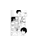

Ảnh 1: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



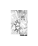

Ảnh 2: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



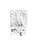

Ảnh 3: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



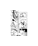

Ảnh 4: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



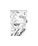

Ảnh 5: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



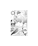

Ảnh 6: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



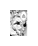

Ảnh 7: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



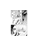

Ảnh 8: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



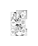

Ảnh 9: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



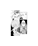

Ảnh 10: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



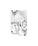

Ảnh 11: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



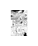

Ảnh 12: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



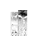

Ảnh 13: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



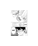

Ảnh 14: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512



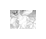

Ảnh 15: Gốc (2568x1920) ➔ Đã nén hiển thị (26x19) do MAX_PIXELS=512



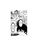

Ảnh 16: Gốc (1350x1920) ➔ Đã nén hiển thị (18x26) do MAX_PIXELS=512


### KẾT QUẢ GEN STORY (STREAMING) ###



OutOfMemoryError: CUDA out of memory. Tried to allocate 1.30 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 16.12 GiB is allocated by PyTorch, and 1.43 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [7]:
# =====================================================================
# --- 1. CHẠY RAW INFERENCE (BASELINE) & XỬ LÝ MAX PIXEL ---
# =====================================================================
gc.collect()
torch.cuda.empty_cache()
FastVisionModel.for_inference(model)

MAX_PIXELS_LIMIT = 512

# LỌC: Tìm các test_sample có tổng số lượng ảnh <= 10
valid_samples = []
for data_item in data_list:
    content_list = data_item['prompt'][0]['content']
    img_count = sum(1 for node in content_list if node.get('type') == 'image')
    if 0 < img_count <= 30:
        valid_samples.append(data_item)
        
eval_results = []

if len(valid_samples) > 0:
    # Lặp qua tất cả các sample thỏa mãn điều kiện
    for selected_data in valid_samples:
# Lấy deepcopy prompt template
        test_sample = copy.deepcopy(selected_data['prompt'])
        ref_story = selected_data['answer']
        
        # SỬA Ở ĐÂY: Lấy thẳng list PIL Images đã được load sẵn từ lúc build dataset!
        raw_images = selected_data['images']
                
        # Tạo prompt text (Template chat)
        text_prompt = tokenizer.apply_chat_template(
            test_sample,
            tokenize=False,
            add_generation_prompt=True
        )
        
        print(f"--- Đang xử lý sample có chứa {len(raw_images)} ảnh ---")
        
        # Constraint 2: Thể hiện display adaption dựa trên MAX_PIXELS_LIMIT trước khi ném vào model
        if len(raw_images) > 0:
            for i, img in enumerate(raw_images):
                w, h = img.size
                total_pixels = w * h
                
                # Tính toán việc Resize giả lập giống hành vi nén dưới gầm của model
                if total_pixels > MAX_PIXELS_LIMIT:
                    scale = math.sqrt(MAX_PIXELS_LIMIT / total_pixels)
                    new_w, new_h = int(w * scale), int(h * scale)
                    display_img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
                else:
                    display_img = img
                    
                disp_w, disp_h = display_img.size
                dpi = 100 
                
                fig = plt.figure(figsize=(disp_w / dpi, disp_h / dpi), dpi=dpi)
                ax = fig.add_axes([0, 0, 1, 1])
                ax.imshow(display_img)
                ax.axis('off')
                plt.show()
                
                print(f"Ảnh {i+1}: Gốc ({w}x{h}) ➔ Đã nén hiển thị ({disp_w}x{disp_h}) do MAX_PIXELS={MAX_PIXELS_LIMIT}\n")

        # Xử lý Inputs cho Mô hình
        inputs = tokenizer(
            text=[text_prompt],
            images=raw_images,
            return_tensors="pt",
            max_pixels=MAX_PIXELS_LIMIT
        ).to("cuda")

        print("\n### KẾT QUẢ GEN STORY (STREAMING) ###\n")
        # Tích hợp Streamer để theo dõi từng Token
        streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
        
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=2048, 
                use_cache=True,
                temperature=0.65,    
                top_p=0.95,          
                repetition_penalty=1.15,
                pad_token_id=tokenizer.eos_token_id,
                streamer=streamer
            )
            
        prompt_len = inputs["input_ids"].shape[-1]
        generated_ids = outputs[0][prompt_len:]
        generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
        raw_inference_output = generated_text

        # Dọn dẹp VRAM sau khi pass qua Model sinh inference
        del inputs, outputs
        torch.cuda.empty_cache()

        test_gen = extract_solution(raw_inference_output)
        print(f"Extracted story:\n {test_gen}")
        print("\n" + "="*60)
        print("STARTING AI STORY SIMILARITY EVALUATION BY GEMMA-4")
        print("="*60)
        
        # Hứng kết quả (Giả định hàm này trả về string JSON như bạn mô tả)
        eval_output = evaluate_story_similarity(ref_story, test_gen)
        eval_results.append(str(eval_output))
        
else:
    print("Không tìm thấy dữ liệu nào có số lượng ảnh <= 10 trong list.")

# =====================================================================
# --- 3. DÙNG REGEX TRÍCH XUẤT ĐIỂM VÀ TÍNH TRUNG BÌNH ---
# =====================================================================
if eval_results:
    char_scores = []
    plot_scores = []
    setting_scores = []
    themes_scores = []
    overall_scores = []

    # Quét regex qua toàn bộ list kết quả đã hứng
    for text in eval_results:
        char_match = re.search(r'"Characters_Score"\s*:\s*(\d+)', text)
        plot_match = re.search(r'"Plot_Score"\s*:\s*(\d+)', text)
        setting_match = re.search(r'"Setting_Score"\s*:\s*(\d+)', text)
        themes_match = re.search(r'"Themes_Score"\s*:\s*(\d+)', text)
        overall_match = re.search(r'"Overall_Score"\s*:\s*(\d+)', text)
        
        if char_match: char_scores.append(float(char_match.group(1)))
        if plot_match: plot_scores.append(float(plot_match.group(1)))
        if setting_match: setting_scores.append(float(setting_match.group(1)))
        if themes_match: themes_scores.append(float(themes_match.group(1)))
        if overall_match: overall_scores.append(float(overall_match.group(1)))

    # Hàm tính Mean
    def calc_mean(scores_list):
        return sum(scores_list) / len(scores_list) if scores_list else 0.0

    print("\n" + "="*60)
    print(f"AVERAGE SCORES ACROSS {len(eval_results)} SAMPLES")
    print("="*60)
    print(f"Characters Mean: {calc_mean(char_scores):.2f}")
    print(f"Plot Mean:       {calc_mean(plot_scores):.2f}")
    print(f"Setting Mean:    {calc_mean(setting_scores):.2f}")
    print(f"Themes Mean:     {calc_mean(themes_scores):.2f}")
    print(f"Overall Mean:    {calc_mean(overall_scores):.2f}")
    print("="*60)